In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
apples = [0.895, 0.91, 0.919, 0.926, 0.929, 0.931]
oranges = [0.962, 0.944, 0.91, 0.863, 0.834, 0.821]
years = [2010, 2011, 2012, 2013, 2014, 2015]

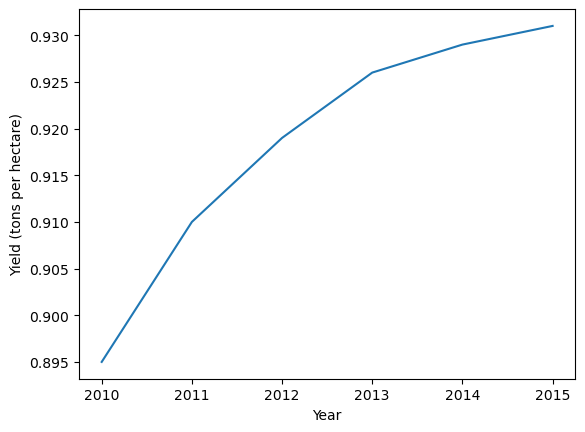

In [3]:
plt.plot(years, apples)
plt.xlabel("Year")
plt.ylabel("Yield (tons per hectare)");

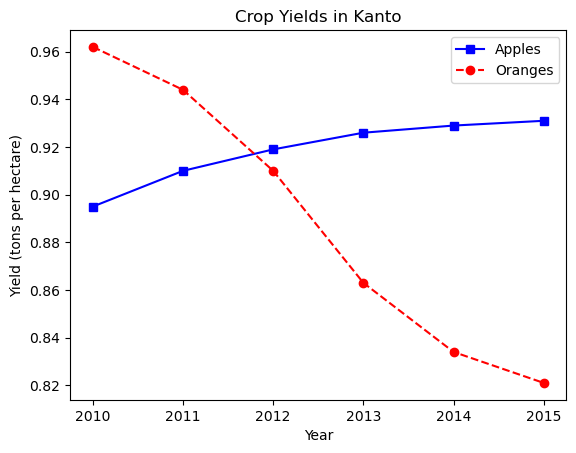

In [4]:
plt.plot(years, apples, 's-b', label='Apples')
plt.plot(years, oranges, 'o--r', label='Oranges')

plt.xlabel('Year')
plt.ylabel('Yield (tons per hectare)')

plt.title("Crop Yields in Kanto")
plt.legend();

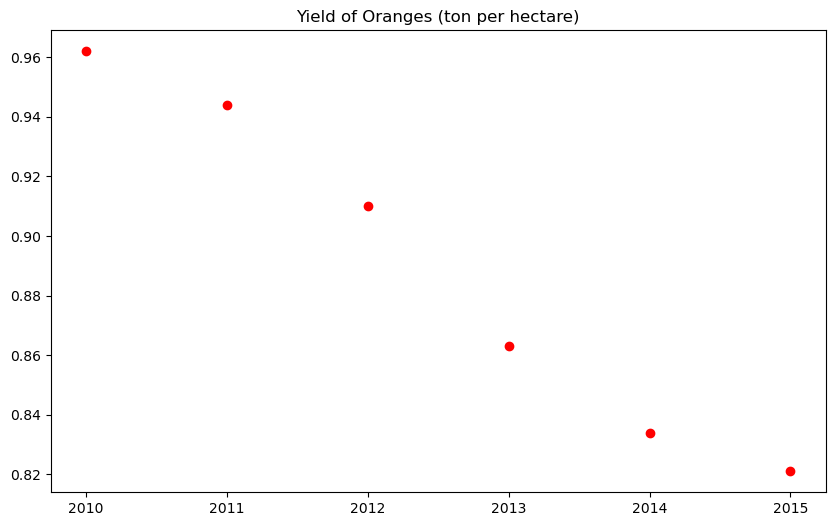

In [5]:
plt.figure(figsize=(10,6))
plt.plot(years, oranges, 'or')
plt.title('Yield of Oranges (ton per hectare)');

# Default Styles using Seaborn

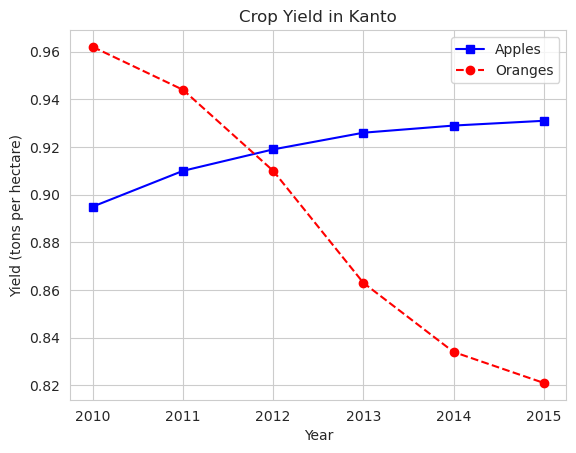

In [6]:
sns.set_style('whitegrid')

plt.plot(years, apples, 's-b', label='Apples')
plt.plot(years, oranges, 'o--r', label='Oranges')

plt.xlabel('Year')
plt.ylabel('Yield (tons per hectare)')

plt.title('Crop Yield in Kanto')
plt.legend();

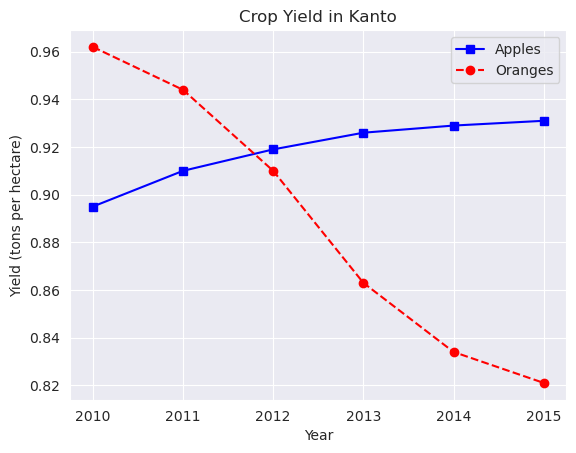

In [7]:
sns.set_style('darkgrid')

plt.plot(years, apples, 's-b', label='Apples')
plt.plot(years, oranges, 'o--r', label='Oranges')

plt.xlabel('Year')
plt.ylabel('Yield (tons per hectare)')

plt.title('Crop Yield in Kanto')
plt.legend();

# Scatter Plot

In [3]:
flowers_df = sns.load_dataset('iris')

In [4]:
flowers_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# use shape to obtain the shape of the entire data set
flowers_df.shape

(150, 5)

In [8]:
# non values from the data set
flowers_df.notna().sum()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [10]:
# to obtain the range of values use index
flowers_df.index

RangeIndex(start=0, stop=150, step=1)

In [13]:
# get the number of rows
len(flowers_df.index)

150

In [11]:
flowers_df.sepal_length.max()

np.float64(7.9)

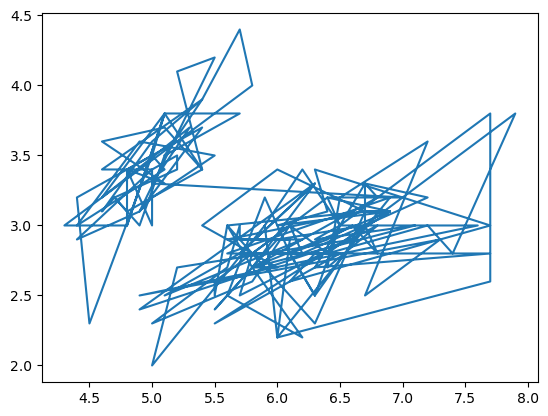

In [14]:
plt.plot(flowers_df.sepal_length, flowers_df.sepal_width);

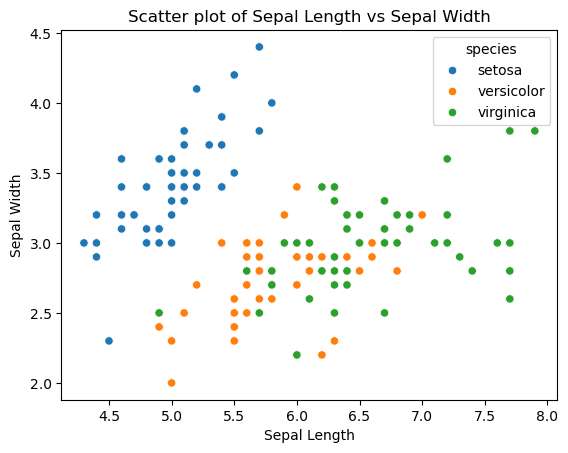

In [16]:
sns.scatterplot(x='sepal_length', y='sepal_width', data=flowers_df, hue='species')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Scatter plot of Sepal Length vs Sepal Width');

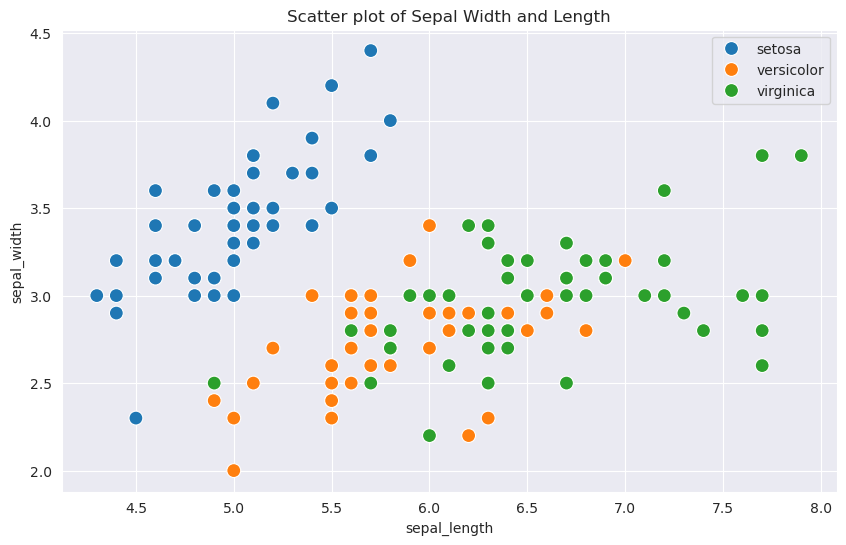

In [14]:
plt.figure(figsize=(10,6))
plt.title('Scatter plot of Sepal Width and Length')
sns.scatterplot(
    x=flowers_df.sepal_length,
    y=flowers_df.sepal_width,
    hue=flowers_df.species.tolist(),
    s=100);

## Analysis Question You Can Answer  

### 1. Basic Statistics

In [18]:
flowers_df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [20]:
#which species had the largests petal length
flowers_df.groupby('species')['petal_length'].mean()

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64

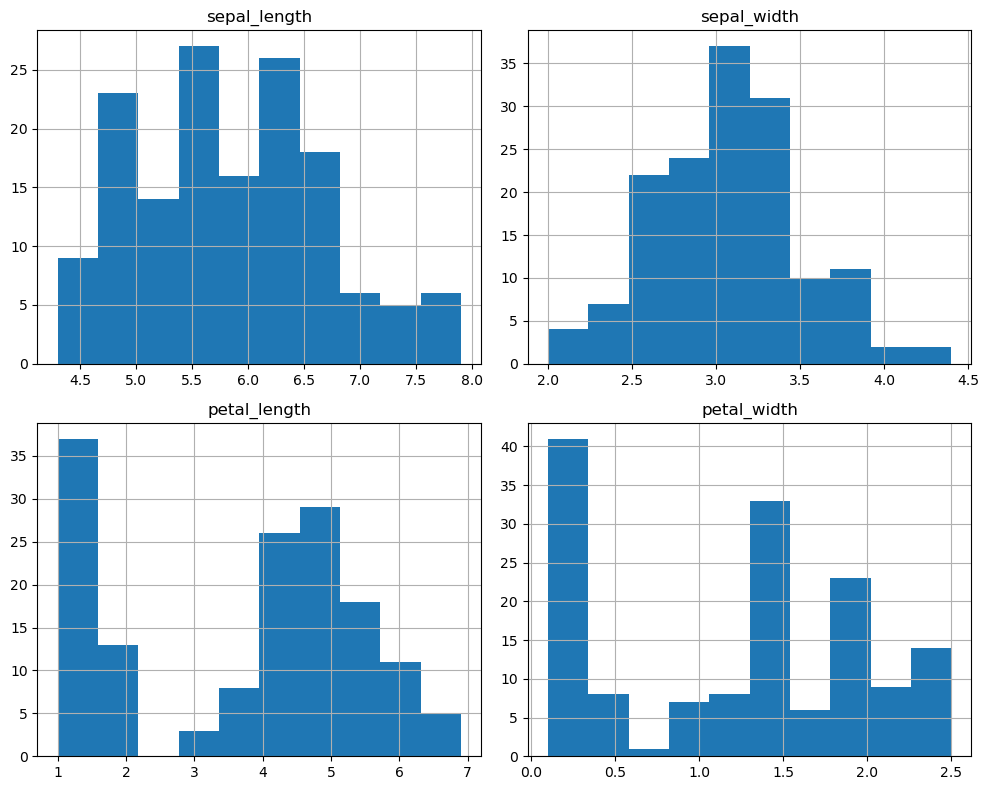

In [21]:
# Histogram for all numeric columns
flowers_df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

### 2. Distribution of Each Feature

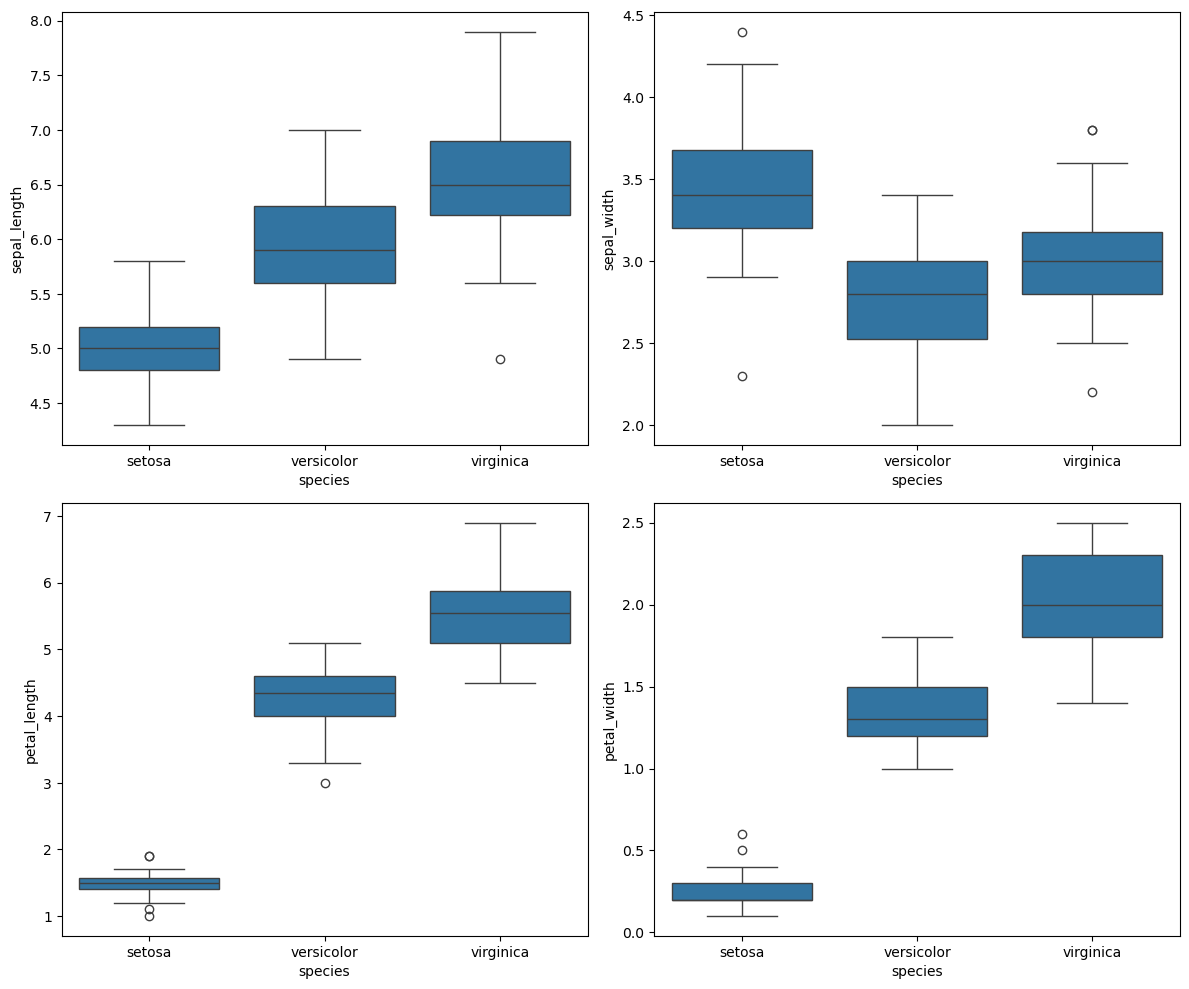

In [23]:
# Box plots by species
fig, axes = plt.subplots(2, 2, figsize=(12,10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, feature in enumerate(features):
    sns.boxplot(x='species', y=feature, data=flowers_df, ax=axes[i//2, i%2])
plt.tight_layout()
plt.show()

- Are the features normally distributed?
- Which species has the most variation in sepal length?

## 3. Relationships Between Features

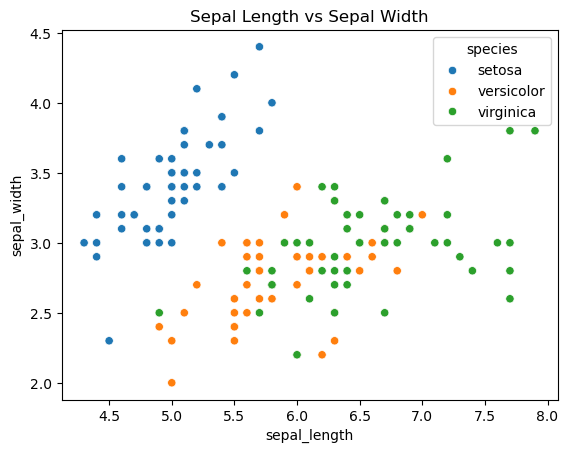

In [25]:
# Scatter plot: sepal length, vs sepal width (colored by species)
sns.scatterplot(flowers_df, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Length vs Sepal Width')
plt.show()

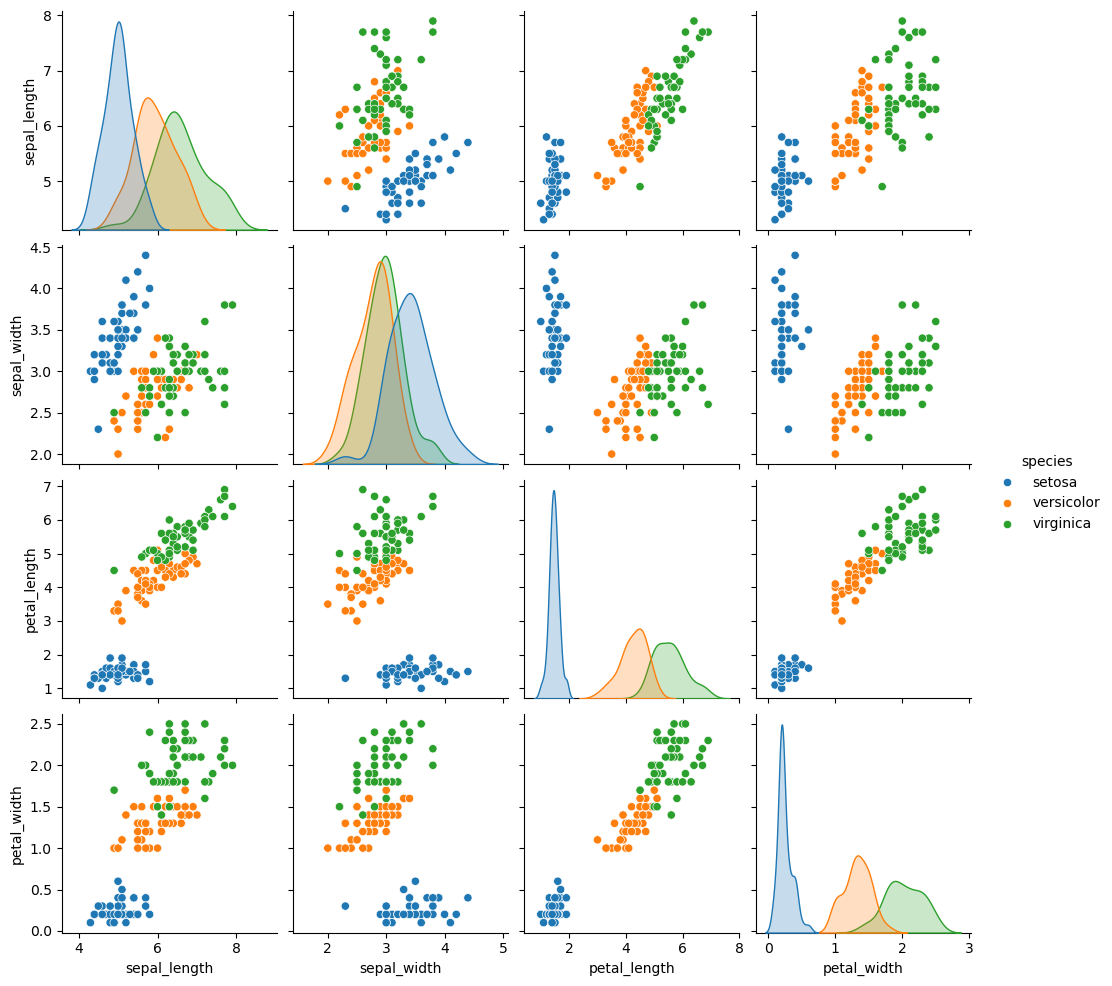

In [24]:
# Pairplot (all feature relationships)
sns.pairplot(flowers_df, hue='species')
plt.show()

- Which two features best distinguish the species?

### 4. Correlation Analysis

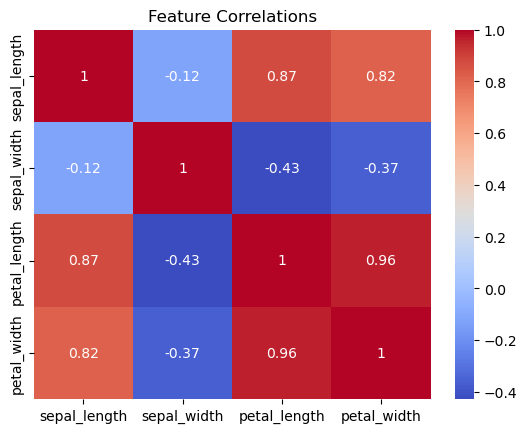

In [27]:
# Correlation matrix
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr = flowers_df[numeric_cols].corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

### 5. Species Comparison

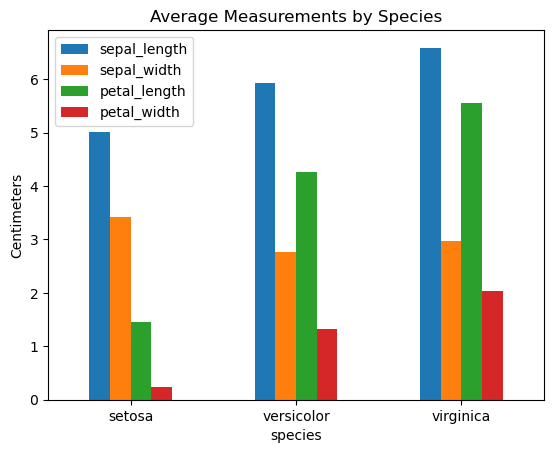

In [28]:
# Grouped bar chart
flowers_df.groupby('species')[numeric_cols].mean().plot(kind='bar')
plt.title('Average Measurements by Species')
plt.ylabel('Centimeters')
plt.xticks(rotation=0)
plt.show()